<a href="https://colab.research.google.com/github/bahmedx/733/blob/main/Hands_On_Project_1_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install and Import Libraries**

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in notebook
%matplotlib inline

# **Load the Dataset**

In [4]:
# Load Titanic dataset
df = sns.load_dataset('titanic')

# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# **Explore the Dataset (EDA)**

In [30]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
 15  Age_Group    891 non-null    object  
dtypes: bool(2), category(2), float64(2), int64(4), object(6)
memory usage: 87.6+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# **Data Cleaning**

In [31]:
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [32]:
def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'

df['Age_Group'] = df['age'].apply(age_group)

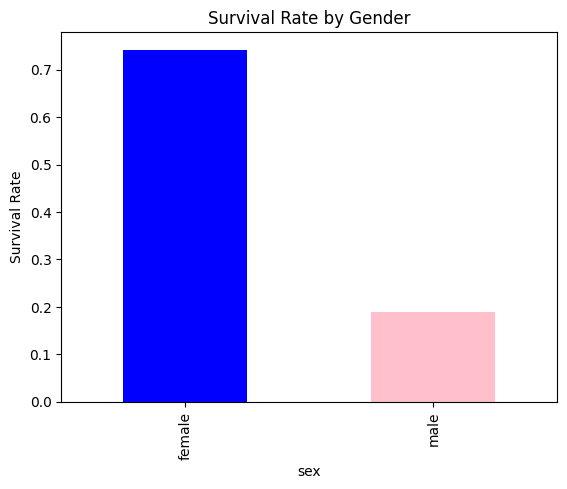

In [33]:
survival_gender = df.groupby('sex')['survived'].mean()

survival_gender.plot(
    kind='bar',
    color=['blue','pink']
)

plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

/tmp/ipykernel_683/4126119127.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_class = df.groupby('class')['survived'].mean()


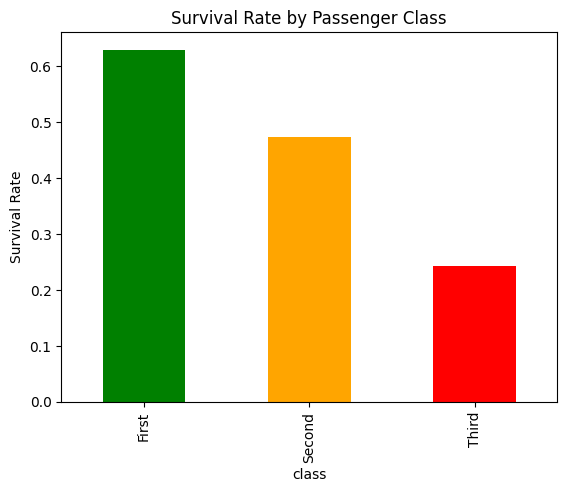

In [34]:
survival_class = df.groupby('class')['survived'].mean()

survival_class.plot(
    kind='bar',
    color=['green','orange','red']
)

plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

In [36]:
female_survivors = df[
    (df['sex'] == 'female') &
    (df['survived'] == 1)
]

print(len(female_survivors))

third_class_males = df[
    (df['sex'] == 'male') &
    (df['class'] == 'Third')
]

print(len(third_class_males))

233
347


In [37]:
grouped = df.groupby(
    ['sex','class']
)['survived'].mean()

print(grouped)

sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64


/tmp/ipykernel_683/671669691.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(


In [38]:
pivot = pd.pivot_table(
    df,
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean'
)

pivot

/tmp/ipykernel_683/2852844023.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [39]:
age_info = pd.DataFrame({
    'Age_Group':['Child','Adult','Senior'],
    'Priority':['High','Normal','Medium']
})

merged_df = pd.merge(
    df,
    age_info,
    on='Age_Group',
    how='left'
)

In [40]:
for group in df['Age_Group'].unique():
    count = len(df[df['Age_Group'] == group])
    print(group, count)


Adult 752
Child 113
Senior 26


# **Plot 1 - Passenger Age Distribution**

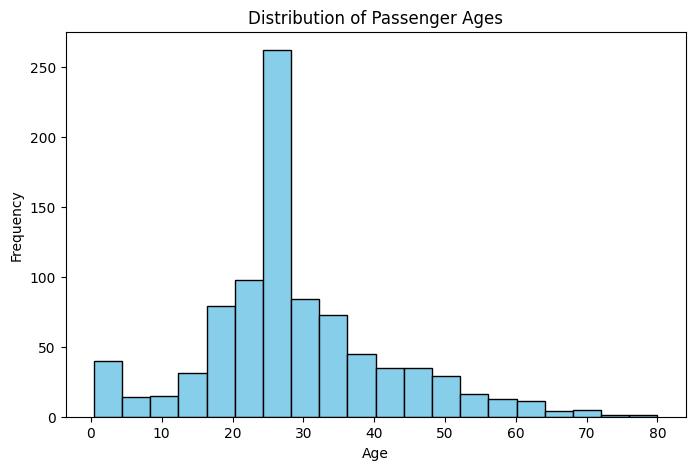

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

# **Plot 2 - Survival by Passenger Class**

/tmp/ipykernel_683/1474893319.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_class = df.groupby('class')['survived'].mean()


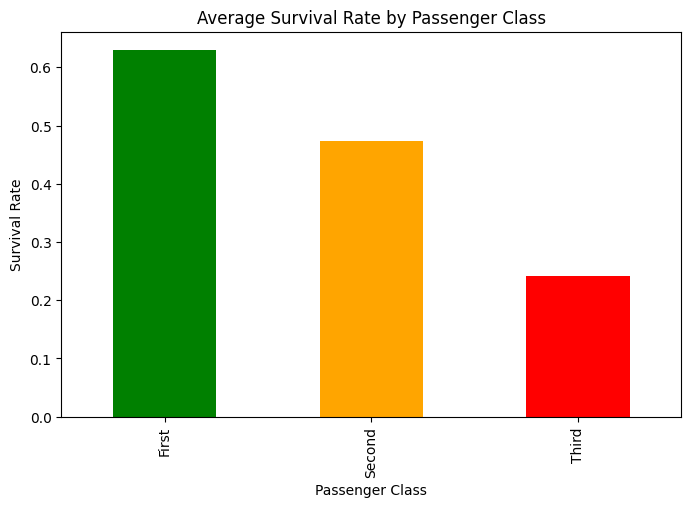

In [11]:
survival_by_class = df.groupby('class')['survived'].mean()

plt.figure(figsize=(8,5))

survival_by_class.plot(
    kind='bar',
    color=['green','orange','red']
)

plt.title('Average Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.show()

# **Data Manipulation - Filtering**

In [16]:
# Female Survivors
female_survivors = df[
    (df['sex'] == 'female') &
    (df['survived'] == 1)
]

female_survivors.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [17]:
# Passengers Older Than 50
older_passengers = df[df['age'] > 50]

older_passengers.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
15,1,2,female,55.0,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
33,0,2,male,66.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
54,0,1,male,65.0,0,1,61.9792,C,First,man,True,B,Cherbourg,no,False


# **Data Manipulation - Grouping**

In [20]:
# Average Age by Class
average_age = df.groupby('class')['age'].mean()

print(average_age)

class
First     36.812130
Second    29.765380
Third     25.932627
Name: age, dtype: float64


/tmp/ipykernel_683/2879084243.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_age = df.groupby('class')['age'].mean()


In [21]:
# Survival Rate by Gender
survival_rate = df.groupby('sex')['survived'].mean()

print(survival_rate)

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


# **Data Manipulation - Merge**

In [22]:
class_info = pd.DataFrame({
    'class': ['First', 'Second', 'Third'],
    'Class_Level': [1, 2, 3]
})

class_info

,class,Class_Level
0,First,1
1,Second,2
2,Third,3


In [23]:
merged_df = pd.merge(
    df,
    class_info,
    on='class',
    how='left'
)

merged_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Class_Level
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,3
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,3
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,3


# **Data Manipulation - Reshape (Pivot Table)**

In [24]:
pivot_table = pd.pivot_table(
    df,
    values='survived',
    index='sex',
    columns='class',
    aggfunc='mean'
)

pivot_table

/tmp/ipykernel_683/590689685.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(


class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


# **Custom Function**

In [25]:
def age_category(age):
    if age < 18:
        return "Child"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

df['Age_Group'] = df['age'].apply(age_category)

df[['age', 'Age_Group']].head()

,age,Age_Group
0,22.0,Adult
1,38.0,Adult
2,26.0,Adult
3,35.0,Adult
4,35.0,Adult


# **Use a Loop**

In [26]:
groups = ['Child', 'Adult', 'Senior']

for group in groups:
    count = len(df[df['Age_Group'] == group])
    print(group, ":", count)

Child : 113
Adult : 752
Senior : 26


# **NumPy Operations**

In [28]:
ages = np.array(df['age'])

print("Mean Age:", np.mean(ages))
print("Maximum Age:", np.max(ages))
print("Minimum Age:", np.min(ages))
print("Standard Deviation:", np.std(ages))

Mean Age: 29.36158249158249
Maximum Age: 80.0
Minimum Age: 0.42
Standard Deviation: 13.012388272793666


# **Final Insights**

In [29]:
print("Total Passengers:", len(df))
print("Total Survivors:", df['survived'].sum())

print("\nSurvival Rate:")
print(round(df['survived'].mean()*100,2), "%")

Total Passengers: 891
Total Survivors: 342

Survival Rate:
38.38 %
